In [1]:
# @title
!pip install meteostat

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 17.6 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pa

In [2]:
# @title
!pip install meteostat statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path
from meteostat import Station, daily
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import classification_report, confusion_matrix

try:
    from google.colab import files
except ImportError:
    files = None

OUTPUT_DIR = Path("results_images")
OUTPUT_DIR.mkdir(exist_ok=True)
CITY_SLUGS = {
    "Baguio City": "baguio",
    "Manila": "manila",
}


def dashboard_image_path(algorithm, label, task_slug):
    city_slug = CITY_SLUGS.get(label, label.lower().replace(" city", "").replace(" ", "_"))
    return OUTPUT_DIR / f"{algorithm}_{city_slug}_{task_slug}.png"


def save_dashboard_plot(fig, algorithm, label, task_slug):
    output_path = dashboard_image_path(algorithm, label, task_slug)
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved graph to {output_path}")
    if files is not None:
        files.download(str(output_path))



In [3]:
start_date = datetime(2020, 1, 1)
end_date   = datetime.now()

from meteostat import Station, daily, Point

# Station objects for Baguio and Manila
station_baguio = Station('98328')
station_manila = Station('98425')

df_baguio = daily(station_baguio, start=start_date, end=end_date).fetch()
df_manila = daily(station_manila, start=start_date, end=end_date).fetch()

print("Data for Baguio City (Station 98328):")
if df_baguio is not None:
    display(df_baguio.head())
else:
    print("No data fetched for Baguio City.")

print("\nData for Manila (Station 98425):")
if df_manila is not None:
    display(df_manila.head())
else:
    print("No data fetched for Manila.")

Data for Baguio City (Station 98328):


,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
time,,,,,,,,,,,
2020-01-01,19.0,15.2,25.0,76,<NA>,<NA>,7.9,<NA>,1014.3,<NA>,<NA>
2020-01-02,19.0,15.8,24.6,79,<NA>,<NA>,6.5,<NA>,1014.6,<NA>,<NA>
2020-01-03,17.9,14.0,23.2,77,<NA>,<NA>,5.1,<NA>,1013.6,<NA>,<NA>
2020-01-04,17.4,12.2,23.2,75,<NA>,<NA>,7.3,<NA>,1012.2,<NA>,<NA>
2020-01-05,17.7,14.2,22.6,76,<NA>,<NA>,9.2,<NA>,1012.2,<NA>,<NA>



Data for Manila (Station 98425):


,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
time,,,,,,,,,,,
2020-01-01,27.3,24.9,29.6,73,0.3,<NA>,8.2,<NA>,1015.8,<NA>,<NA>
2020-01-02,28.2,24.3,31.2,73,0.3,<NA>,8.8,<NA>,1016.4,<NA>,<NA>
2020-01-03,27.3,25.4,30.7,68,0.0,<NA>,7.9,<NA>,1015.2,<NA>,<NA>
2020-01-04,27.0,22.5,30.8,70,<NA>,<NA>,6.9,<NA>,1013.5,<NA>,<NA>
2020-01-05,27.9,24.0,30.4,69,<NA>,<NA>,8.2,<NA>,1013.5,<NA>,<NA>


=== ARIMA Rainfall Analysis ? Baguio City ===
Forecasting... (This may take a moment)
Overall Classification Accuracy: 60.76%
              precision    recall  f1-score   support

       Light       0.81      0.65      0.72       161
    Moderate       0.29      0.29      0.29        66
       Heavy       0.57      0.74      0.64       117

    accuracy                           0.61       344
   macro avg       0.56      0.56      0.55       344
weighted avg       0.63      0.61      0.61       344

Saved graph to results_images/arima_baguio_intensity.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

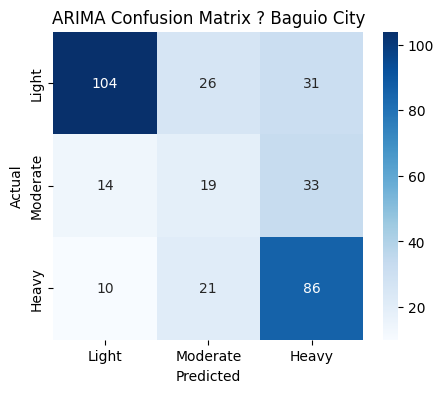

=== ARIMA Rainfall Analysis ? Manila ===
Forecasting... (This may take a moment)
Overall Classification Accuracy: 61.63%
              precision    recall  f1-score   support

       Light       0.88      0.66      0.76       185
    Moderate       0.24      0.35      0.28        57
       Heavy       0.57      0.68      0.62       102

    accuracy                           0.62       344
   macro avg       0.56      0.56      0.55       344
weighted avg       0.68      0.62      0.64       344

Saved graph to results_images/arima_manila_intensity.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

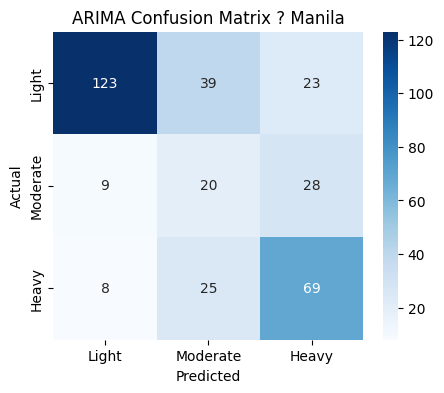

In [5]:
# 1. Data Fetching (Keep your original logic)
start_date = datetime(2020, 1, 1)
end_date = datetime.now()

station_baguio = Station('98328')
station_manila = Station('98425')

df_baguio = daily(station_baguio, start=start_date, end=end_date).fetch()
df_manila = daily(station_manila, start=start_date, end=end_date).fetch()

# 2. Classification Logic
def classify_intensity(mm):
    if mm < 2.5: return 0  # Light
    elif mm < 7.5: return 1 # Moderate
    else: return 2         # Heavy

def run_arima_weather(df, label):
    print(f"=== ARIMA Rainfall Analysis ({label}) ===")

    # Preprocessing
    series = df['prcp'].fillna(0).asfreq('D').fillna(0)

    # Split: 85% Train, 15% Test (Standard for time series)
    size = int(len(series) * 0.85)
    train, test = series[0:size], series[size:len(series)]

    # 3. Fit ARIMA Model
    history = [x for x in train]
    predictions = []

    print("Forecasting... (This may take a moment)")
    for t in range(len(test)):
        model = ARIMA(history, order=(5,1,0))
        model_fit = model.fit()
        output = model_fit.forecast()
        yhat = output[0]
        predictions.append(max(0, yhat))
        history.append(test.iloc[t])

    # 4. Convert Continuous Predictions to Classes
    y_test_classes = [classify_intensity(x) for x in test]
    y_pred_classes = [classify_intensity(x) for x in predictions]

    # 5. Metrics & Visualization
    acc = np.mean(np.array(y_test_classes) == np.array(y_pred_classes)) * 100
    print(f"Overall Classification Accuracy: {acc:.2f}%")
    print(classification_report(y_test_classes, y_pred_classes, target_names=["Light", "Moderate", "Heavy"], zero_division=0))

    cm = confusion_matrix(y_test_classes, y_pred_classes)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Light", "Moderate", "Heavy"],
                yticklabels=["Light", "Moderate", "Heavy"],
                ax=ax)
    ax.set_title(f"ARIMA Confusion Matrix ({label})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    save_dashboard_plot(fig, "arima", label, "intensity")
    plt.show()

# Run for both cities
run_arima_weather(df_baguio, "Baguio City")
run_arima_weather(df_manila, "Manila")




=== ARIMA Rainfall Amount Predictor - Baguio City ===
Computing Forecasts...
MSE: 340.05 | MAE: 6.76 | R?: 0.186 | Accuracy (approx): 24.05%
Saved graph to results_images/arima_baguio_rain.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

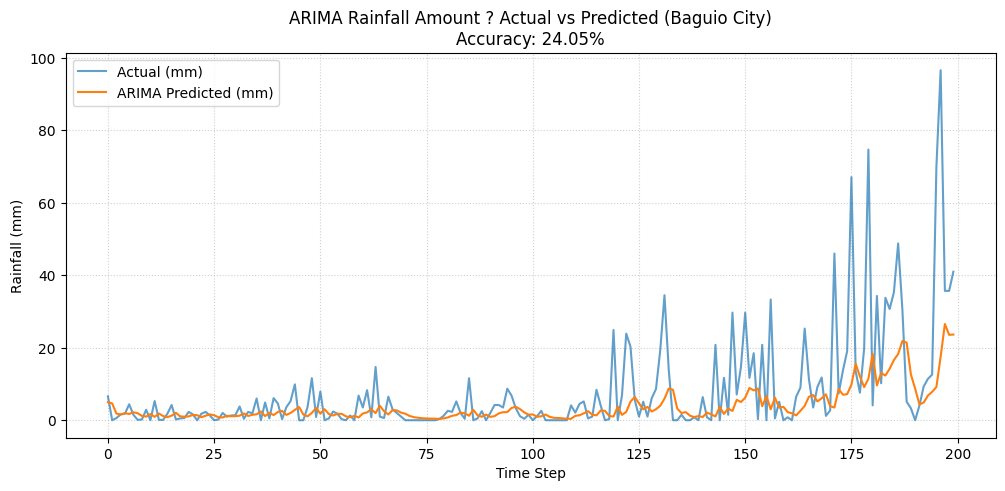

=== ARIMA Rainfall Amount Predictor - Manila ===
Computing Forecasts...
MSE: 73.31 | MAE: 3.90 | R?: 0.245 | Accuracy (approx): 26.81%
Saved graph to results_images/arima_manila_rain.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

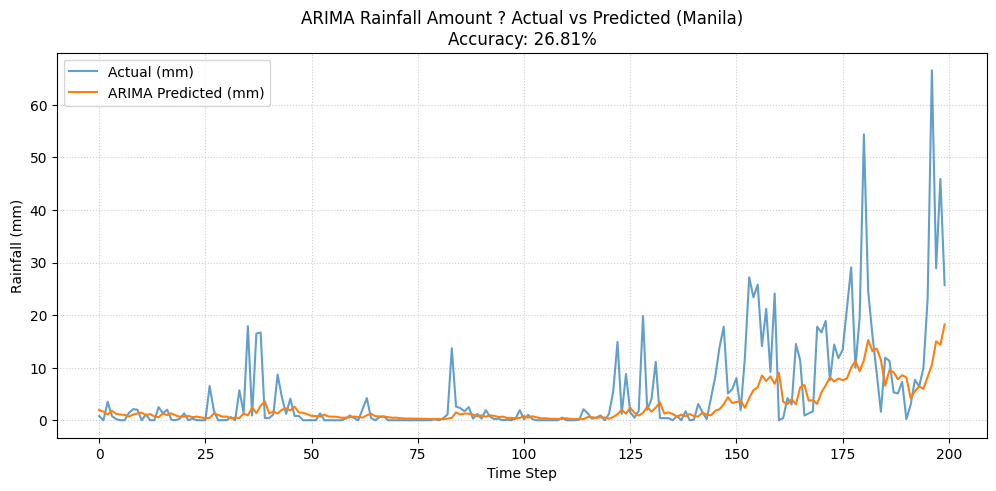

In [7]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def run_rain_regressor_arima(df, label):
    print(f"=== ARIMA Rainfall Amount Predictor - {label} ===")

    series_mm = df['prcp'].fillna(0).asfreq('D').fillna(0)
    series_log = np.log1p(series_mm)

    cut = int(len(series_log) * 0.8)
    train_log = series_log[:cut]
    test_log = series_log[cut:]
    test_mm = series_mm[cut:]

    history = [x for x in train_log]
    predictions_log = []

    print("Computing Forecasts...")
    for t in range(len(test_log)):
        model = ARIMA(history, order=(5, 1, 1))
        model_fit = model.fit()
        yhat_log = model_fit.forecast()[0]
        predictions_log.append(yhat_log)
        history.append(test_log.iloc[t])

    y_pred_mm = np.expm1(np.array(predictions_log))
    y_pred_mm = np.where(y_pred_mm < 0, 0, y_pred_mm)

    mse = mean_squared_error(test_mm, y_pred_mm)
    mae = mean_absolute_error(test_mm, y_pred_mm)
    r2 = r2_score(test_mm, y_pred_mm)
    mean_val = np.mean(test_mm) if np.mean(test_mm) != 0 else 1e-6
    acc_pct = max(0, (1 - mae / mean_val) * 100)

    print(f"MSE: {mse:.2f} | MAE: {mae:.2f} | R2: {r2:.3f} | Accuracy (approx): {acc_pct:.2f}%")

    N = min(200, len(test_mm))
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(test_mm.values[:N], label="Actual (mm)", alpha=0.7)
    ax.plot(y_pred_mm[:N], label="ARIMA Predicted (mm)")
    ax.set_title(f"ARIMA Rainfall Amount ? Actual vs Predicted ({label})\nAccuracy: {acc_pct:.2f}%")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Rainfall (mm)")
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)
    save_dashboard_plot(fig, "arima", label, "rain")
    plt.show()

    return y_pred_mm

# RUN
arima_baguio_preds = run_rain_regressor_arima(df_baguio, "Baguio City")
arima_manila_preds = run_rain_regressor_arima(df_manila, "Manila")




=== ARIMA Temperature Predictor ? Baguio City ===
Forecasting... (Updating model daily)
MSE: 0.292 | MAE: 0.411 | R?: 0.816 | Accuracy: 97.85%
Saved graph to results_images/arima_baguio_temp.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

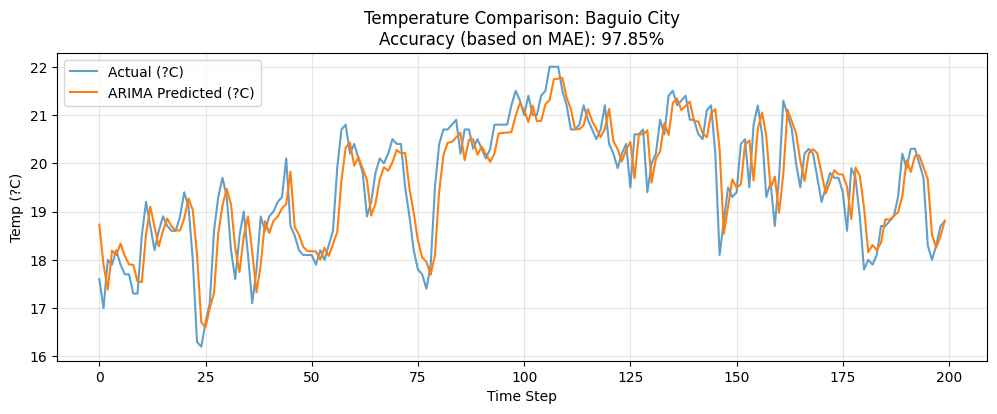

=== ARIMA Temperature Predictor ? Manila ===
Forecasting... (Updating model daily)
MSE: 0.315 | MAE: 0.427 | R?: 0.841 | Accuracy: 98.50%
Saved graph to results_images/arima_manila_temp.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

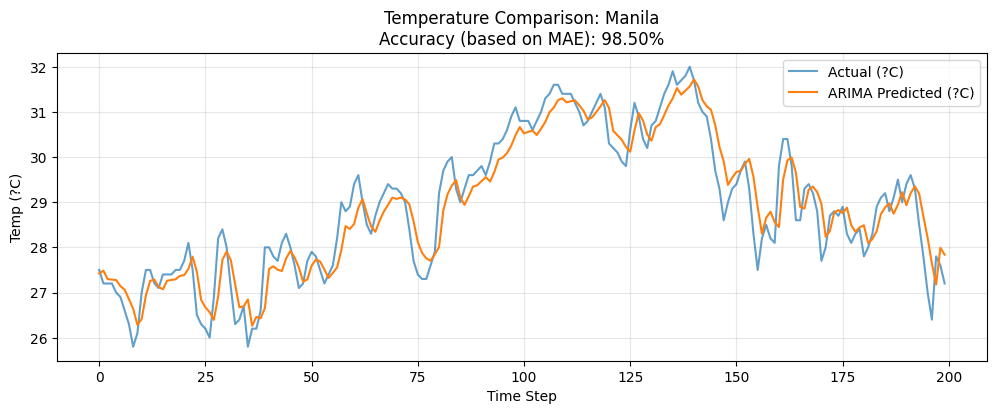

In [8]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def run_temp_regressor_arima(df, label):
    print(f"=== ARIMA Temperature Predictor ({label}) ===")

    series = pd.to_numeric(df['temp'], errors='coerce')
    series = series.interpolate().ffill().bfill()
    series.index = pd.to_datetime(series.index)
    series = series.asfreq('D').ffill()

    split_point = int(len(series) * 0.8)
    train, test = series[:split_point], series[split_point:]

    history = [x for x in train]
    predictions = []

    print("Forecasting... (Updating model daily)")
    for t in range(len(test)):
        model = ARIMA(history, order=(1, 1, 1))
        model_fit = model.fit()
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        history.append(test.iloc[t])

    y_test = test.values
    y_pred = np.array(predictions)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    acc_pct = max(0, (1 - mae / np.mean(y_test)) * 100)

    print(f"MSE: {mse:.3f} | MAE: {mae:.3f} | R2: {r2:.3f} | Accuracy: {acc_pct:.2f}%")

    N = min(200, len(y_test))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(y_test[:N], label="Actual (C)", alpha=0.7)
    ax.plot(y_pred[:N], label="ARIMA Predicted (C)")
    ax.set_title(f"Temperature Comparison: {label}\nAccuracy (based on MAE): {acc_pct:.2f}%")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Temp (C)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    save_dashboard_plot(fig, "arima", label, "temp")
    plt.show()

    return y_pred

# Running the corrected code
# Ensure df_baguio and df_manila are already defined from your previous cells
temp_preds_bag = run_temp_regressor_arima(df_baguio, "Baguio City")
temp_preds_man = run_temp_regressor_arima(df_manila, "Manila")




=== ARIMA Wind Speed Predictor ? Baguio City ===
Computing Walk-Forward Forecasts...
MSE: 5.051 | MAE: 1.460 | R?: 0.418 | Accuracy: 69.72%
Saved graph to results_images/arima_baguio_wind.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

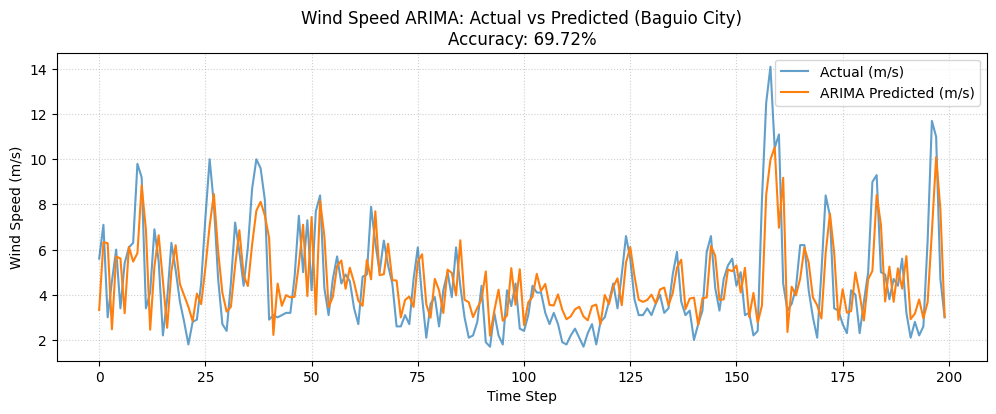

=== ARIMA Wind Speed Predictor ? Manila ===
Computing Walk-Forward Forecasts...
MSE: 1.560 | MAE: 0.766 | R?: 0.690 | Accuracy: 90.74%
Saved graph to results_images/arima_manila_wind.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

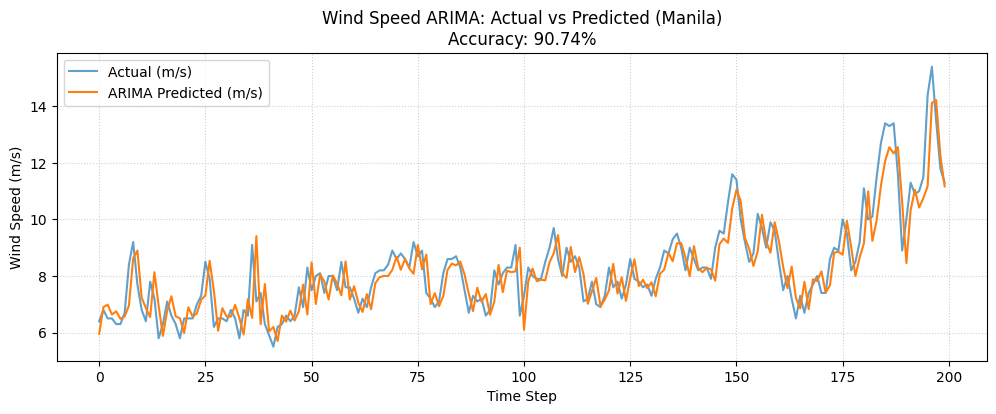

In [10]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def run_wind_regressor_arima(df, label):
    print(f"=== ARIMA Wind Speed Predictor ({label}) ===")

    series = pd.to_numeric(df['wspd'], errors='coerce')
    series = series.interpolate().ffill().bfill()
    series.index = pd.to_datetime(series.index)
    series = series.asfreq('D').ffill()

    split_point = int(len(series) * 0.8)
    train, test = series[:split_point], series[split_point:]

    history = [x for x in train]
    predictions = []

    print("Computing Walk-Forward Forecasts...")
    for t in range(len(test)):
        model = ARIMA(history, order=(2, 1, 2))
        model_fit = model.fit()
        yhat = model_fit.forecast()[0]
        predictions.append(max(0, yhat))
        history.append(test.iloc[t])

    y_test = test.values
    y_pred = np.array(predictions)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    mean_val = np.mean(y_test) if np.mean(y_test) != 0 else 1e-6
    acc_pct = max(0, (1 - mae / mean_val) * 100)

    print(f"MSE: {mse:.3f} | MAE: {mae:.3f} | R2: {r2:.3f} | Accuracy: {acc_pct:.2f}%")

    N = min(200, len(y_test))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(y_test[:N], label="Actual (m/s)", alpha=0.7)
    ax.plot(y_pred[:N], label="ARIMA Predicted (m/s)")
    ax.set_title(f"Wind Speed ARIMA: Actual vs Predicted ({label})\nAccuracy: {acc_pct:.2f}%")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Wind Speed (m/s)")
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)
    save_dashboard_plot(fig, "arima", label, "wind")
    plt.show()

    return y_pred

# Execute for both cities
wind_preds_bag = run_wind_regressor_arima(df_baguio, "Baguio City")
wind_preds_man = run_wind_regressor_arima(df_manila, "Manila")




=== ARIMA Pressure Predictor ? Baguio City ===
Forecasting Pressure (hPa)...
MSE: 1.961 | MAE: 0.886 | RMSE: 1.400
R?: 0.775 | Accuracy (norm): 52.56%
Saved graph to results_images/arima_baguio_pressure.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

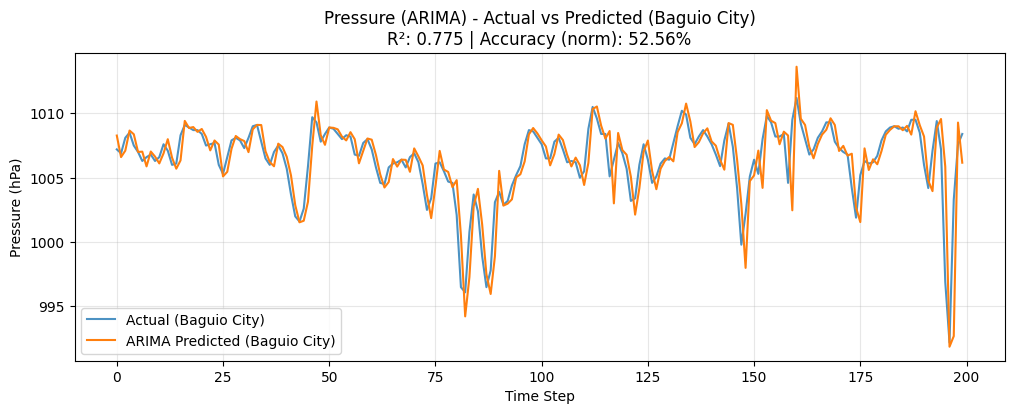

=== ARIMA Pressure Predictor ? Manila ===
Forecasting Pressure (hPa)...
MSE: 1.387 | MAE: 0.785 | RMSE: 1.178
R?: 0.804 | Accuracy (norm): 55.72%
Saved graph to results_images/arima_manila_pressure.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

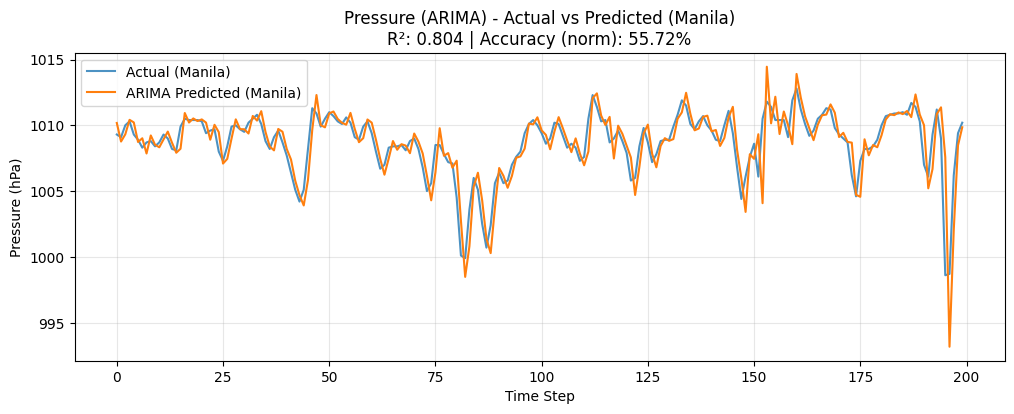

In [12]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def run_press_regressor_arima(df, label):
    print(f"=== ARIMA Pressure Predictor - {label} ===")

    series = pd.to_numeric(df['pres'], errors='coerce')
    series = series.interpolate().ffill().bfill()
    series.index = pd.to_datetime(series.index)
    series = series.asfreq('D').ffill()

    split_point = int(len(series) * 0.85)
    train, test = series[:split_point], series[split_point:]

    history = [x for x in train]
    predictions = []

    print("Forecasting Pressure (hPa)...")
    for t in range(len(test)):
        model = ARIMA(history, order=(1, 1, 1))
        model_fit = model.fit()
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        history.append(test.iloc[t])

    y_test_hpa = test.values
    y_pred_hpa = np.array(predictions)

    mse = mean_squared_error(y_test_hpa, y_pred_hpa)
    mae = mean_absolute_error(y_test_hpa, y_pred_hpa)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_hpa, y_pred_hpa)
    std = np.std(y_test_hpa) if np.std(y_test_hpa) != 0 else 1e-6
    acc_pct = max(0, 100 * (1 - rmse / std))

    print(f"MSE: {mse:.3f} | MAE: {mae:.3f} | RMSE: {rmse:.3f}")
    print(f"R2: {r2:.3f} | Accuracy (norm): {acc_pct:.2f}%")

    N = min(200, len(y_test_hpa))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(y_test_hpa[:N], label=f"Actual ({label})", alpha=0.8)
    ax.plot(y_pred_hpa[:N], label=f"ARIMA Predicted ({label})")
    ax.set_title(
    f"Pressure (ARIMA) - Actual vs Predicted ({label})\n"
    f"R²: {r2:.3f} | Accuracy (norm): {acc_pct:.2f}%")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Pressure (hPa)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    save_dashboard_plot(fig, "arima", label, "pressure")
    plt.show()

    return y_pred_hpa

# Running for both cities
press_preds_bag = run_press_regressor_arima(df_baguio, "Baguio City")
press_preds_man = run_press_regressor_arima(df_manila, "Manila")


